# Particle in a box with a central barrier: Rayleigh-Ritz method

Units $\hbar = m = 1$. Box $[-L, L]$ with a barrier $V_0$ on $[-a, a]$:

$$H = -\tfrac12 \tfrac{d^2}{dx^2} + V(x), \qquad V(x) = \begin{cases} V_0 & |x|<a \\ 0 & \text{otherwise}\end{cases}$$

**Method.** Expand $\psi = \sum_{k=1}^{N} c_k \phi_k$ in the eigenfunctions of the empty box,

$$\phi_k(x) = \frac{1}{\sqrt L}\begin{cases}\cos\frac{k\pi x}{2L} & k \text{ odd}\\ \sin\frac{k\pi x}{2L} & k\text{ even}\end{cases}, \qquad E_k^0 = \frac{k^2\pi^2}{8L^2}.$$

The Hamiltonian matrix is $H_{k'k} = E_k^0\,\delta_{k'k} + V_0\int_{-a}^{a}\phi_{k'}\phi_k\,dx$. Diagonalizing it gives upper bounds on the true energies that decrease monotonically as $N$ grows (variational principle).

In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [2]:
V0, L, a = 10, 1, 0.5

In [3]:
def phi(k, x):
    """Normalized eigenfunctions of the empty box, k = 1, 2, ..."""
    arg = k*np.pi*x/(2*L)
    return (np.cos(arg) if k % 2 == 1 else np.sin(arg)) / np.sqrt(L)

def V_elem(kp, k):
    """<kp|V|k>. Different parity -> integrand is odd -> exactly 0."""
    if (k - kp) % 2:
        return 0.0
    return V0*quad(lambda x: phi(kp, x)*phi(k, x), -a, a)[0]

def get_H(N):
    H = np.zeros((N, N))
    for k in range(N):
        H[k, k] = (k+1)**2*np.pi**2/(8*L**2) + V_elem(k+1, k+1)
        for kp in range(k):
            H[kp, k] = H[k, kp] = V_elem(kp+1, k+1)
    return H

def PSI(c, x):
    return sum(ck*phi(k, x) for k, ck in enumerate(c, start=1))

## Ground state for increasing basis size

1 [9.41679941]
3 [ 7.98175937  9.9348022  16.47731204]
30 [ 7.76087916  8.75066739 16.18050252 25.5989029 ]


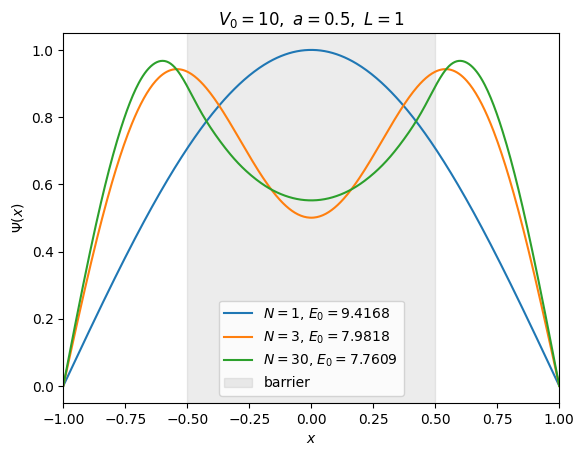

In [4]:
x = np.linspace(-L, L, 500)
for N in [1, 3, 30]:
    E, C = np.linalg.eigh(get_H(N))   # eigenvectors are the COLUMNS of C
    psi = PSI(C[:, 0], x)
    if psi[len(x)//2] < 0:             # eigenvector sign is arbitrary
        psi = -psi
    plt.plot(x, psi, label=f'$N={N}$, $E_0={E[0]:.4f}$')
    print(N, E[:4])

plt.axvspan(-a, a, color='gray', alpha=0.15, label='barrier')
plt.legend()
plt.title(f'$V_0={V0},\\ a={a},\\ L={L}$')
plt.xlim([-L, L]); plt.xlabel('$x$'); plt.ylabel(r'$\Psi(x)$')
plt.show()

## Convergence of the lowest levels
Each curve should decrease monotonically toward its limit.

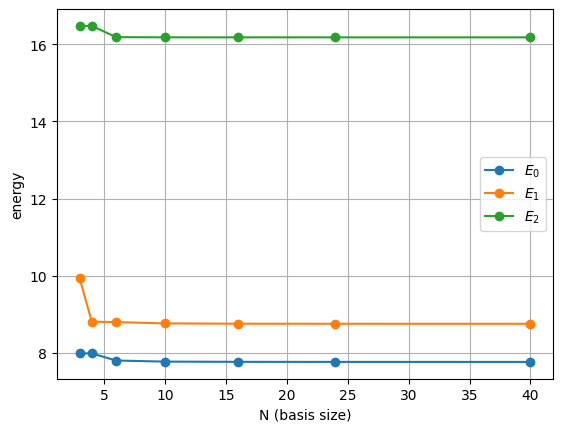

In [5]:
Ns = [3, 4, 6, 10, 16, 24, 40]
E_N = np.array([np.linalg.eigvalsh(get_H(N))[:3] for N in Ns])
for j in range(3):
    plt.plot(Ns, E_N[:, j], 'o-', label=f'$E_{j}$')
plt.xlabel('N (basis size)'); plt.ylabel('energy'); plt.legend(); plt.grid()
plt.show()

## Ground and first excited state (tunnel splitting)
For $E < V_0$ the two lowest levels form a nearly degenerate pair: the symmetric and antisymmetric combinations of states localized in the two wells.

E0, E1 = [7.76069523 8.75043565]   splitting = 0.9897404189295536


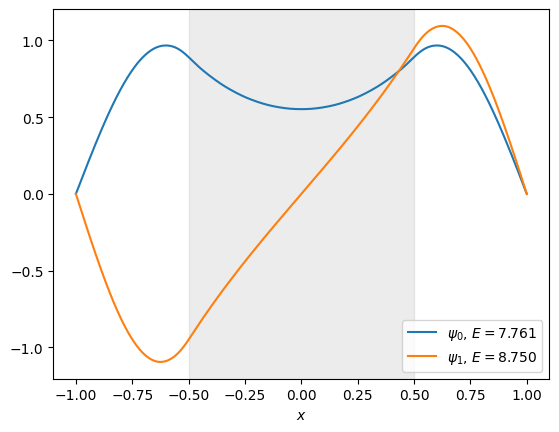

In [6]:
N = 40
E, C = np.linalg.eigh(get_H(N))
print('E0, E1 =', E[:2], '  splitting =', E[1]-E[0])
for j in range(2):
    psi = PSI(C[:, j], x)
    plt.plot(x, psi*np.sign(psi[np.argmax(abs(psi))]), label=f'$\\psi_{j}$, $E={E[j]:.3f}$')
plt.axvspan(-a, a, color='gray', alpha=0.15)
plt.legend(); plt.xlabel('$x$'); plt.show()